In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
# Import countries polygons
fp = os.path.join('data', 'ne_50m_admin_0_countries', 'ne_50m_admin_0_countries.shp')
countries = gpd.read_file(fp)

# Simplify column names
countries.columns = countries.columns.str.lower()

# Select columns for analysis
countries = countries[['admin', 'type', 'geometry']]

countries.head()

,admin,type,geometry
0,Zimbabwe,Sovereign country,"POLYGON ((31.28789 -22.40205, 31.19727 -22.344..."
1,Zambia,Sovereign country,"POLYGON ((30.39609 -15.64307, 30.25068 -15.643..."
2,Yemen,Sovereign country,"MULTIPOLYGON (((53.08564 16.64839, 52.58145 16..."
3,Vietnam,Sovereign country,"MULTIPOLYGON (((104.06396 10.39082, 104.08301 ..."
4,Venezuela,Sovereign country,"MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9..."


<Axes: >

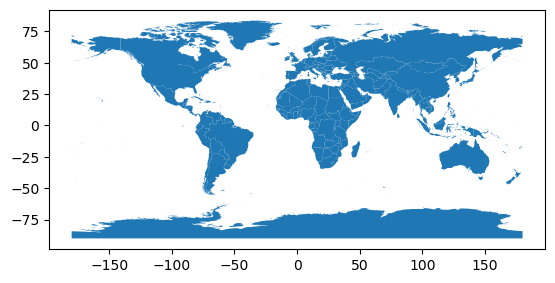

In [3]:
countries.plot()

In [4]:
# Import Arctic communities data
URL = 'https://cn.dataone.org/cn/v2/resolve/urn%3Auuid%3Aed7718ae-fb0d-43dd-9270-fbfe80bfc7a4'
communities = gpd.read_file(URL)

communities.head()

,name,population,country,geoname-id,geometry
0,Udomlya,32373,RU,452949,POINT (34.99250 57.87944)
1,Valmiera,26963,LV,453754,POINT (25.42751 57.54108)
2,Ventspils,42644,LV,454310,POINT (21.57288 57.38988)
3,Vec-Liepāja,85260,LV,454432,POINT (21.01667 56.53333)
4,Tukums,18348,LV,454768,POINT (23.15528 56.96694)


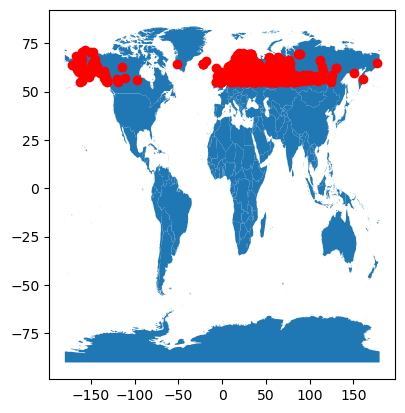

In [5]:
# Verify CRSs match
assert countries.crs == communities.crs

fig, ax = plt.subplots()
countries.plot(ax=ax)
communities.plot(ax=ax, color='red')
plt.show()

In [6]:
country_names = pd.read_csv('https://raw.githubusercontent.com/MEDS-eds-220/MEDS-eds-220-course/refs/heads/main/book/chapters/lesson-12-merge-data/country_names.csv')
country_names

,country,admin
0,RU,Russia
1,LV,Latvia
2,EE,Estonia
3,LT,Lithuania
4,SE,Sweden
5,BY,Belarus
6,FI,Finland
7,NO,Norway
8,DK,Denmark
9,FO,Faroe Islands


In [7]:
# Create data frame with number of communities per country
n_comms = communities.groupby('country').size().reset_index(name='n_communities')

In [8]:
# Create set to check for intersections in column names
common_columns = set(countries.columns).intersection(n_comms.columns)

# Check if there are any common columns
if len(common_columns) != 0:
    print(f"Common columns: {common_columns}")
else:
    print("No columns in common")

No columns in common


## Check-in 1

Wrap up previous code in a function.

In [9]:
def check_common_columns(df1, df2):
    """
    Prints a message depending on whether df1 & df2 have columns in common.
    """

    common_columns = set(df1.columns).intersection(df2.columns)
    
    if len(common_columns) != 0:
        print(f'Common columns: {common_columns}')
    else:
        print("No columns in common")

In [10]:
check_common_columns(countries, n_comms)

No columns in common


## Merging dataframes

In [11]:
# Check for common columns first
check_common_columns(n_comms, country_names)

Common columns: {'country'}


In [12]:
# Merge n_commns & country names
n_comms = pd.merge(n_comms, country_names, how='left', on='country')
n_comms

,country,n_communities,admin
0,AX,1,Aland Islands
1,BY,8,Belarus
2,CA,7,Canada
3,DK,72,Denmark
4,EE,14,Estonia
5,FI,98,Finland
6,FO,1,Faroe Islands
7,GB,96,United Kingdom
8,GL,1,Greenland
9,IS,5,Iceland


## Check-in 2
Join with `countries` df but as an inner join

In [13]:
check_common_columns(n_comms, countries)

Common columns: {'admin'}


In [14]:
arctic_countries = pd.merge(countries, n_comms, how='inner', on='admin')

In [15]:
arctic_countries.head()

,admin,type,geometry,country,n_communities
0,United States of America,Country,"MULTIPOLYGON (((-132.74687 56.52568, -132.7576...",US,115
1,United Kingdom,Country,"MULTIPOLYGON (((-2.66768 51.62300, -2.74214 51...",GB,96
2,Sweden,Sovereign country,"MULTIPOLYGON (((19.07646 57.83594, 18.99375 57...",SE,133
3,Russia,Sovereign country,"MULTIPOLYGON (((145.88154 43.45952, 145.89561 ...",RU,774
4,Norway,Sovereign country,"MULTIPOLYGON (((20.62217 69.03687, 20.49199 69...",NO,48


In [16]:
# Confirm that Aland Islands is nowhere in data frame
'Aland Islands' not in countries.values

True

In [17]:
# View original number
original = arctic_countries.loc[arctic_countries['admin'] == 'Finland', 'n_communities'].iloc[0]
original

98

In [19]:
# Update value due to inner join data loss
arctic_countries.loc[arctic_countries['admin'] == 'Finland', 'n_communities'] += 1

In [20]:
# View updated number
arctic_countries.loc[arctic_countries['admin'] == 'Finland', 'n_communities'].iloc[0]

99

<Axes: >

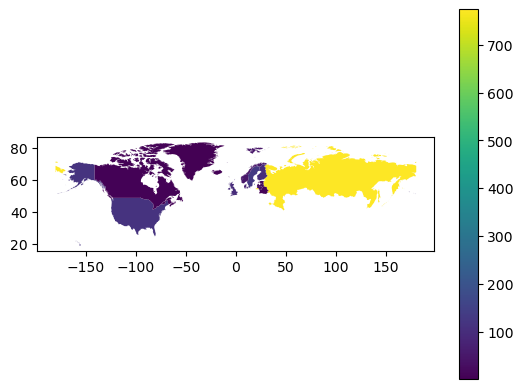

In [21]:
# Plot choropleth map
arctic_countries.plot(column='n_communities', legend=True)

In [22]:
if arctic_countries.crs == 'EPSG:4326': # type:ignore
    print('Converting to EPSG:3413')
    
    arctic_countries = arctic_countries.to_crs('EPSG:3413') #type:ignore
else:
    print('CRS is already EPSG:3413')
    

Converting to EPSG:3413


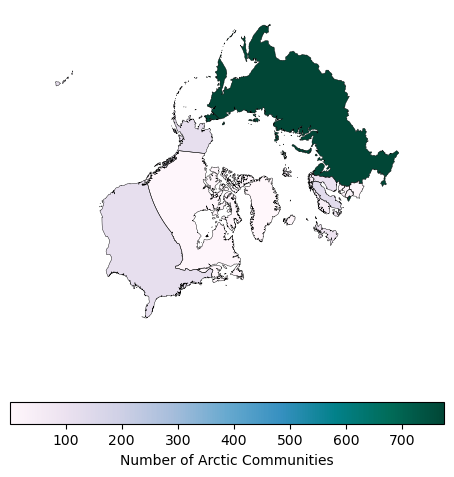

In [29]:
# Plot reprojected map
fig, ax = plt.subplots(figsize=(8,6))

ax.axis('off')

arctic_countries.boundary.plot(ax=ax, color='black', linewidth = 0.3)

arctic_countries.plot(ax=ax, column = 'n_communities', cmap='PuBuGn', legend=True, legend_kwds={'label':"Number of Arctic Communities", 'orientation':'horizontal', 'shrink':0.7})

plt.show()